# Day 2 — Text Representation: TF-IDF & Embeddings

## Objective

In this notebook, we will convert cleaned IMDB movie reviews into numerical representations using TF-IDF and explore word embeddings.

The main goals are to:

- Apply TF-IDF vectorization to cleaned text.
- Train a simple text classification baseline.
- Evaluate the model using Precision, Recall, and F1-score.
- Explore pre-trained word embeddings and semantic similarity.
- Compare TF-IDF with embedding-based representations.
- Document which representation is more suitable for sentiment analysis.

In [22]:
import re
import string

import numpy as np
import pandas as pd

import nltk

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

import gensim.downloader as api

In [7]:
df = pd.read_csv(
    "IMDB Dataset.csv",
    on_bad_lines="skip"
)

print(df.shape)
df.head()

(50000, 2)


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [13]:
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

In [14]:
def preprocess_text(text):
    # 1. Lowercase
    text = text.lower()

    # 2. Remove HTML tags and replace them with spaces
    text = re.sub(r'<.*?>', ' ', text)

    # 3. Tokenize
    tokens = word_tokenize(text)

    # 4. Remove punctuation and numbers
    tokens = [
        word for word in tokens
        if word not in string.punctuation and not word.isdigit()
    ]

    # 5. Remove stop words while preserving negations
    important_negations = {"not", "no", "never"}

    tokens = [
        word for word in tokens
        if word not in stop_words or word in important_negations
    ]

    # 6. Lemmatization
    tokens = [
        lemmatizer.lemmatize(word)
        for word in tokens
    ]

    return tokens

In [15]:
df["cleaned_tokens"] = df["review"].apply(preprocess_text)

df["cleaned_text"] = df["cleaned_tokens"].apply(" ".join)

In [16]:
df[["review", "cleaned_text", "sentiment"]].head()

,review,cleaned_text,sentiment
0,One of the other reviewers has mentioned that ...,one reviewer mentioned watching oz episode 'll...,positive
1,A wonderful little production. <br /><br />The...,wonderful little production filming technique ...,positive
2,I thought this was a wonderful way to spend ti...,thought wonderful way spend time hot summer we...,positive
3,Basically there's a family where a little boy ...,basically 's family little boy jake think 's z...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",petter mattei 's `` love time money '' visuall...,positive


##  Train/Test Split

Before applying TF-IDF, the dataset is divided into training and testing sets.

The training set will be used to fit the TF-IDF vectorizer and train the classification model, while the test set will be kept unseen for final evaluation.

A stratified split is used to preserve the balance between positive and negative sentiment classes.

- **80%** of the data is used for training.
- **20%** of the data is used for testing.
- `random_state=42` ensures reproducibility.
- `stratify=y` maintains the original class distribution.

In [17]:
X = df["cleaned_text"]

y = df["sentiment"].map({
    "positive": 1,
    "negative": 0
})

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples :", len(X_test))

Training samples: 40000
Testing samples : 10000


##  TF-IDF Vectorization

TF-IDF (Term Frequency–Inverse Document Frequency) is used to convert the cleaned text into numerical feature vectors.

It assigns higher weights to words that are important and distinctive within a document, while reducing the importance of words that appear frequently across many documents.

The vectorizer is fitted only on the training data to prevent data leakage, then applied to both the training and testing sets.

In this experiment, the vocabulary is limited to the **5,000 most informative features**.

In [18]:
vectorizer = TfidfVectorizer(max_features=5000)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape :", X_test_tfidf.shape)

Training TF-IDF shape: (40000, 5000)
Testing TF-IDF shape : (10000, 5000)


##  Train Baseline Classifier

After converting the reviews into TF-IDF vectors, a Logistic Regression classifier is trained as a simple baseline model for sentiment classification.

Logistic Regression is commonly used with TF-IDF because it is efficient, works well with high-dimensional sparse text features, and provides a strong baseline for text classification.

The model will classify each review as either positive or negative.

In [19]:
model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

model.fit(X_train_tfidf, y_train)

y_pred = model.predict(X_test_tfidf)

print("Model training completed successfully!")

Model training completed successfully!


## Model Evaluation

The trained Logistic Regression model is evaluated on the unseen test set using Accuracy, Precision, Recall, and F1-score.

Since this is a sentiment classification task, the **F1-score** is an important metric because it provides a balance between Precision and Recall.

A classification report is also generated to provide a detailed evaluation for both sentiment classes.

In [20]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("TF-IDF + Logistic Regression Results")
print("-" * 45)
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=["Negative", "Positive"]
))

TF-IDF + Logistic Regression Results
---------------------------------------------
Accuracy : 0.8900
Precision: 0.8825
Recall   : 0.8998
F1-score : 0.8911

Classification Report:
              precision    recall  f1-score   support

    Negative       0.90      0.88      0.89      5000
    Positive       0.88      0.90      0.89      5000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



### Evaluation Results

The TF-IDF + Logistic Regression model achieved an **F1-score of 0.8911** on the test set, with an accuracy of 0.8900.

The Precision (0.8825) and Recall (0.8998) values are also well balanced, indicating that the model performs consistently across both sentiment classes.

The classification report shows an F1-score of **0.89 for both Negative and Positive reviews**, demonstrating balanced performance without a significant bias toward either class.

Overall, TF-IDF combined with Logistic Regression provides a strong and efficient baseline for sentiment classification.

##  Word Embeddings

Word embeddings represent words as dense numerical vectors that capture semantic relationships between words.

Unlike TF-IDF, which focuses on the importance of individual words, embeddings represent words in a continuous vector space where semantically related words tend to have similar representations.

In this section, we will use pre-trained Word2Vec embeddings to explore semantic similarity between words.

In [23]:
word2vec = api.load("word2vec-google-news-300")

[==================================================] 100.0% 1662.8/1662.8MB downloaded


In [25]:
word2vec.most_similar("excellent", topn=5)

[('terrific', 0.7409726977348328),
 ('superb', 0.7062715888023376),
 ('exceptional', 0.681470513343811),
 ('fantastic', 0.6802847981452942),
 ('good', 0.6442928910255432)]

### Semantic Similarity Results

The pre-trained Word2Vec model was used to find words that are semantically similar to selected sentiment-related words.

For the word **"excellent"**, the most similar words included *terrific*, *superb*, *exceptional*, *fantastic*, and *good*.

These results demonstrate that Word2Vec captures semantic relationships between words by representing them as vectors in a continuous vector space.

##  Convert Reviews into Embedding Vectors

Word2Vec provides a numerical vector for each individual word. To represent an entire review, we calculate the average of the vectors of all words that exist in the pre-trained Word2Vec vocabulary.

This produces one fixed-size **300-dimensional vector** for each review.

Words that are not present in the Word2Vec vocabulary are ignored.

In [26]:
def review_to_embedding(review, model):
    vectors = []

    for word in review.split():
        if word in model:
            vectors.append(model[word])

    if len(vectors) == 0:
        return np.zeros(model.vector_size)

    return np.mean(vectors, axis=0)

In [27]:
X_train_embeddings = np.vstack(
    X_train.apply(lambda x: review_to_embedding(x, word2vec))
)

X_test_embeddings = np.vstack(
    X_test.apply(lambda x: review_to_embedding(x, word2vec))
)

In [28]:
print("Training Embeddings shape:", X_train_embeddings.shape)
print("Testing Embeddings shape :", X_test_embeddings.shape)

Training Embeddings shape: (40000, 300)
Testing Embeddings shape : (10000, 300)


##  Train Classifier on Word Embeddings

The generated Word2Vec embeddings are now used as input features for a Logistic Regression classifier.

The same classifier is used to make the comparison with the TF-IDF baseline fair.

The model is trained on the training embeddings and evaluated on the unseen test embeddings using Precision, Recall, and F1-score.

In [29]:
embedding_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

embedding_model.fit(X_train_embeddings, y_train)

y_pred_embeddings = embedding_model.predict(X_test_embeddings)

print("Embedding model training completed successfully!")

Embedding model training completed successfully!


In [30]:
accuracy_emb = accuracy_score(y_test, y_pred_embeddings)
precision_emb = precision_score(y_test, y_pred_embeddings)
recall_emb = recall_score(y_test, y_pred_embeddings)
f1_emb = f1_score(y_test, y_pred_embeddings)

print("Word2Vec + Logistic Regression Results")
print("-" * 45)
print(f"Accuracy : {accuracy_emb:.4f}")
print(f"Precision: {precision_emb:.4f}")
print(f"Recall   : {recall_emb:.4f}")
print(f"F1-score : {f1_emb:.4f}")

Word2Vec + Logistic Regression Results
---------------------------------------------
Accuracy : 0.8569
Precision: 0.8585
Recall   : 0.8546
F1-score : 0.8566


##  TF-IDF vs Word2Vec Comparison

The two text representations were evaluated using the same Logistic Regression classifier and the same train/test split.


| Representation | Accuracy | Precision | Recall | F1-score |
|---|---:|---:|---:|---:|
| TF-IDF | 0.8900 | 0.8825 | 0.8998 | **0.8911** |
| Word2Vec | 0.8569 | 0.8585 | 0.8546 | **0.8566** |


TF-IDF achieved a higher F1-score than the Word2Vec-based representation by **3.45 percentage points**.

For this IMDB sentiment classification task, TF-IDF performed better when combined with Logistic Regression. The Word2Vec representation was created by averaging word vectors, which can lose word order and contextual information.

Therefore, **TF-IDF was selected as the stronger baseline representation for this dataset**, while Word2Vec demonstrated the advantage of representing semantic relationships between words.

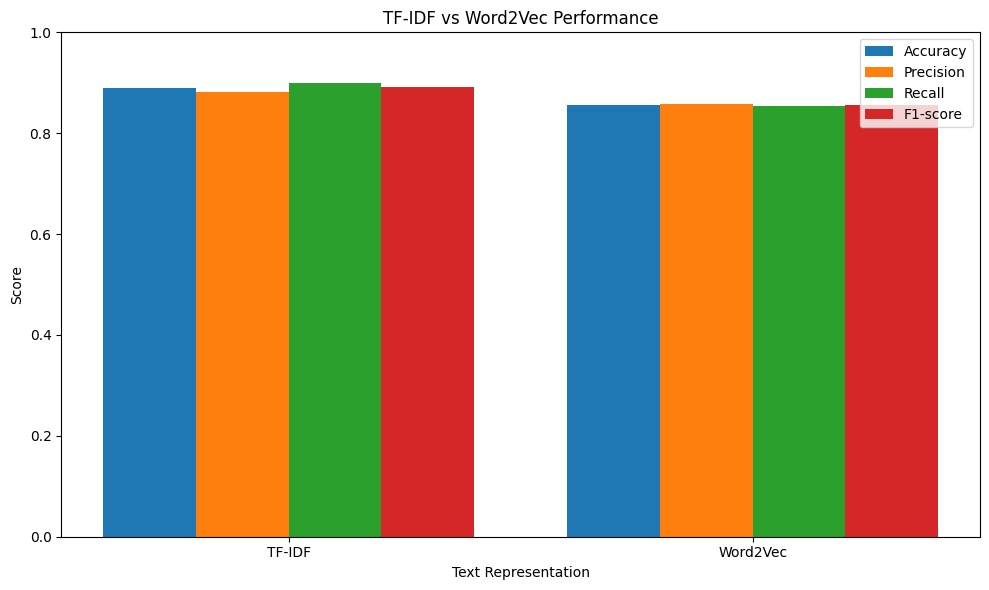

In [31]:
import matplotlib.pyplot as plt
import numpy as np

representations = ["TF-IDF", "Word2Vec"]

accuracy_scores = [accuracy, accuracy_emb]
precision_scores = [precision, precision_emb]
recall_scores = [recall, recall_emb]
f1_scores = [f1, f1_emb]

x = np.arange(len(representations))
width = 0.2

plt.figure(figsize=(10, 6))

plt.bar(x - 1.5 * width, accuracy_scores, width, label="Accuracy")
plt.bar(x - 0.5 * width, precision_scores, width, label="Precision")
plt.bar(x + 0.5 * width, recall_scores, width, label="Recall")
plt.bar(x + 1.5 * width, f1_scores, width, label="F1-score")

plt.xticks(x, representations)
plt.ylabel("Score")
plt.xlabel("Text Representation")
plt.title("TF-IDF vs Word2Vec Performance")
plt.ylim(0, 1)

plt.legend()
plt.tight_layout()
plt.show()

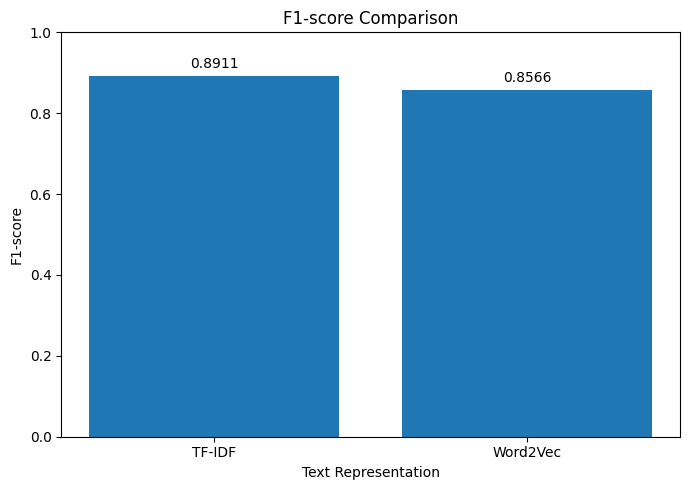

In [32]:
plt.figure(figsize=(7, 5))

bars = plt.bar(
    representations,
    f1_scores
)

plt.ylabel("F1-score")
plt.xlabel("Text Representation")
plt.title("F1-score Comparison")
plt.ylim(0, 1)

for bar, score in zip(bars, f1_scores):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        score + 0.02,
        f"{score:.4f}",
        ha="center"
    )

plt.tight_layout()
plt.show()

##  Representation Selection

Based on the experimental results, **TF-IDF was selected as the preferred text representation** for the IMDB sentiment classification task.

TF-IDF achieved an F1-score of **0.8911**, outperforming the Word2Vec-based representation, which achieved an F1-score of **0.8566**.

The main reasons for selecting TF-IDF are:

- Higher F1-score on the test set.
- Strong and balanced Precision and Recall.
- Simple and computationally efficient.
- Effective for sentiment classification with Logistic Regression.
- Provides interpretable features based on word importance.

Although Word2Vec captures semantic relationships between words, averaging the word vectors into a single review representation can lose word order and contextual information.

Therefore, TF-IDF provides the stronger representation for our current baseline sentiment classification model.

##  Conclusion

In this session, cleaned IMDB movie reviews were converted into numerical representations using two approaches: **TF-IDF** and **Word2Vec embeddings**.

A Logistic Regression classifier was trained and evaluated using the same train/test split.

The results showed that:

- **TF-IDF + Logistic Regression:** F1-score = **0.8911**
- **Word2Vec + Logistic Regression:** F1-score = **0.8566**

TF-IDF achieved the better performance for this sentiment classification task and was therefore selected as the preferred baseline representation.

This experiment also demonstrated that different text representations can significantly affect model performance. While TF-IDF is effective for traditional machine learning models, embedding-based representations provide richer semantic information and can be more useful when combined with neural networks and contextual language models.